测试三 稳定不同初始人口 与  epsilon参数 带来的影响 （啥也没测）

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1. 辅助函数
# ---------------------------
def compute_epsilon(states, alpha, epsilon0):

    p_A = states[:, 1] + states[:, 2] + states[:, 4]  # 取 AS + AI + AR 作为有意识水平
    epsilon = np.where(p_A > alpha, epsilon0, 0.0)
    return epsilon


def compute_effective_awareness(n, states, g_i, R):

    N = len(n)
    M = R.shape[1]
    n_out = n * g_i  
    p_A_res = states[:, 1] + states[:, 2] + states[:, 4]
    tilde_p_A = np.zeros(M)
    for j in range(M):
        numerator = 0.0  # 分子
        denominator = 0.0 # 分母
        for i in range(N):
            flow = n_out[i] * R[i, j]
            numerator += flow * p_A_res[i]
            denominator += flow
        tilde_p_A[j] = numerator / denominator if denominator > 0 else 0.0
    return tilde_p_A

def compute_awareness_conversion(R, lambda1, tilde_p_A):

    N, M = R.shape
    
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(M):
            # 物理层和信息层线共用一个拓扑结构
            prod *= (1 - lambda1 * R[i, j] * tilde_p_A[j])
        r[i] = 1 - prod
    return r

def compute_infection_residence(n, states, g_i, beta_U, beta_A):

    n_remain = n * (1 - g_i)
    p_I = states[:, 2]
    # p_I = np.clip(states[:, 2], 0, 1)  # 确保 p_I ∈ [0,1]
    # 采用 np.power 计算 (1 - lambda * p_I)^(n_remain)
    N_U = 1 - np.power(1 - beta_U * p_I, n_remain)
    N_A = 1 - np.power(1 - beta_A * p_I, n_remain)
    return N_U, N_A

def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):

    N, M = R.shape
    M_U = np.zeros(M)
    M_A = np.zeros(M)
    for j in range(M):
        sum_U = 1.0
        sum_A = 1.0
        for k in range(N):
            n_to_j = n[k] * g_i[k] * R[k, j]
            p_I = states[k, 2]
            sum_U *= np.power(1 - beta_U * p_I, n_to_j)
            sum_A *= np.power(1 - beta_A * p_I, n_to_j)
        M_U[j] = 1 - sum_U
        M_A[j] = 1 - sum_A
    return M_U, M_A

def compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A):

    N, M = R.shape
    Q_U = np.zeros(N)
    Q_A = np.zeros(N)
    for i in range(N):
        sum_MU = np.sum(R[i, :] * M_U)
        sum_MA = np.sum(R[i, :] * M_A)
        Q_U[i] = (1 - g_i[i]) * N_U[i] + g_i[i] * sum_MU
        Q_A[i] = (1 - g_i[i]) * N_A[i] + g_i[i] * sum_MA
    return Q_U, Q_A


def update_states(states, r, Q_U, Q_A, mu1, mu2):

    new_states = np.zeros_like(states)
    US = states[:, 0]
    AS = states[:, 1]
    AI = states[:, 2]
    UR = states[:, 3]
    AR = states[:, 4]
    
    new_states[:, 0] = US * (1 - r) * (1 - Q_U) + AS * mu1 * (1 - Q_U)
    new_states[:, 1] = AS * (1 - mu1) * (1 - Q_A) + US * r * (1 - Q_A)
    new_states[:, 2] = AI * (1 - mu2) + AS * (1 - mu1) * Q_A + AS * mu1 * Q_U + US * (1 - r) * Q_U + US * r * Q_A
    new_states[:, 3] = AI * mu1 * mu2 + AR * mu1 + UR * (1 - r)
    new_states[:, 4] = AR * (1 - mu1) + AI * (1 - mu1) * mu2 + UR * r

    # 归一化每个居住点的状态比例
    row_sums = new_states.sum(axis=1)
    row_sums[row_sums == 0] = 1e-10  # 避免除零
    new_states = new_states / row_sums[:, None]
    return new_states


def update_population(n, states, g_i, epsilon, R, T):

    N, M = R.shape
    F = n * g_i * epsilon

    # 剩余人口和状态
    X = states * n[:, None]
    X_remain = X - (X.T * (g_i * epsilon)).T
    n_remain = n - F

    # 计算中转站流入人口
    m = np.zeros(M)
    m_X = np.zeros((M, 5))
    for j in range(M):
        for i in range(N):
            flow = n[i] * g_i[i] * epsilon[i] * R[i, j]
            m[j] += flow
            m_X[j] += X[i] * g_i[i] * epsilon[i] * R[i, j]

    # 计算返回人口（直接使用 T 矩阵）
    flow_return = np.zeros(N)
    flow_return_X = np.zeros((N, 5))
    for j in range(M):
          for i in range(N):
              flow_return[i] += m[j] * T[i, j]
              flow_return_X[i] +=  m_X[j]  * T[i, j]

    # 更新人口和状态
    n_new = n_remain + flow_return
    X_new = X_remain + flow_return_X
    new_states = X_new / np.clip(n_new[:, None], 1e-10, None)
    return n_new, new_states


# ---------------------------
# 2. 主仿真流程
# ---------------------------
def main_simulation(Time, N, M, params):

    lambda1 = params['lambda1']
    mu1 = params['mu1']
    mu2 = params['mu2']
    beta_U = params['beta_U']
    beta_A = params['beta_A']
    g_global = params['g']
    # gamma_global = params['gamma']
    epsilon0 = params['epsilon0']
    alpha = params['alpha']
    theta = params['theta']
    # kappa = params['kappa']

    # 居住点特异性迁移率和返回率（这里使用常数，可扩展为数组）
    g_i = np.full(N, theta * g_global)

    # 初始化各居住点人口 100-800
    n = np.arange(100, 850, 50, dtype=int)
    states = np.zeros((N, 5))
    states[:, 0] = 0.99  # US
    states[:, 2] = 0.01  # AI
    states = states / states.sum(axis=1, keepdims=True)
    
    # 初始化居住点与中转站之间的权重矩阵 R (N x M)，对称归一化：每个居住点行和为 1
    w = np.random.rand(N, M)
    R = w / w.sum(axis=1, keepdims=True)  # 行归一化（迁移）
    T = w / w.sum(axis=0, keepdims=True)  # 列归一化（返回）

    # 用于记录历史数据
    state_history = np.zeros((Time, N, 5))
    pop_history = np.zeros((Time, N))
    
    for t in range(Time):
        state_history[t] = states
        pop_history[t] = n
        
        # 1. 计算当前居住点局部有意识比例 p^A = AS + AI + AR
        # 2. 计算激活因子 epsilon: 若 p^A > alpha 则 epsilon = epsilon0，否则 0
        epsilon = compute_epsilon(states, alpha, epsilon0)
        
        # 2.5. 更新居住点的人口及状态（基于 MIR 过程） n_new为更新后的居住点人口数，states_new为更新后的居住点状态比例
        n_new, states_new = update_population(n, states, g_i, epsilon, R, T)

        # 3. 计算中转站的过客有效意识比例 tilde_p^A
        tilde_p_A = compute_effective_awareness(n, states_new, g_i, R)
        # 4. 计算居住点的意识转换概率 r
        r = compute_awareness_conversion(R, lambda1, tilde_p_A)
        # print('t', t, 'r', r)
        
        # 5. 计算居住点内部感染风险
        N_U, N_A = compute_infection_residence(n, states_new, g_i, beta_U, beta_A)
        # 6. 计算中转站层面的感染风险
        M_U, M_A = compute_infection_transit(n, states_new, g_i, R, beta_U, beta_A)
        # 7. 综合计算每个居住点的总体感染概率 Q
        Q_U, Q_A = compute_overall_infection(n, states_new, g_i, R, N_U, N_A, M_U, M_A)
        
        # 8. 更新居住点内部的疾病/意识状态
        states = update_states(states_new, r, Q_U, Q_A, mu1, mu2)
        n = n_new    

    return state_history, pop_history


Running simulations: 100%|██████████| 1/1 [00:00<00:00,  9.24it/s]


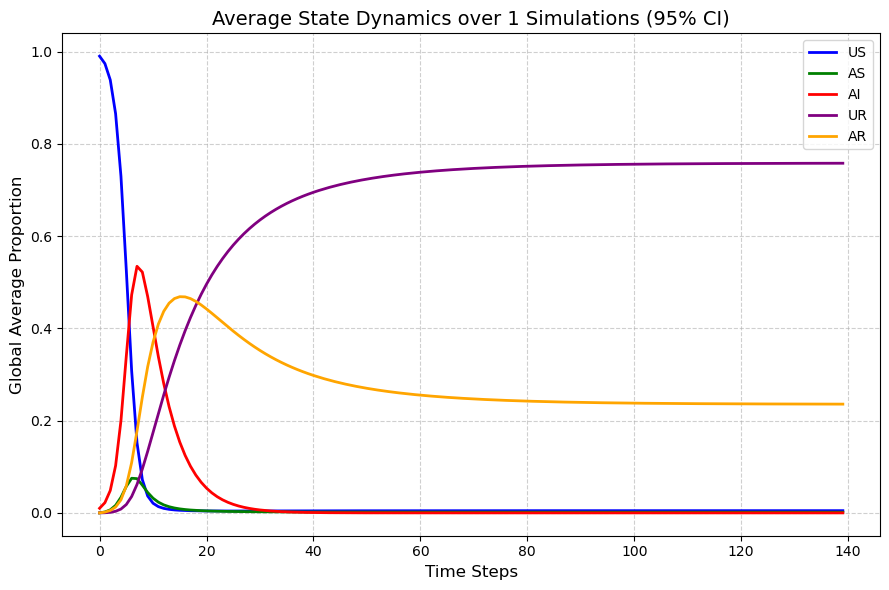

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # 用于显示进度条

# 参数设置
Time = 140               # 总时间步数
N = 15                 # 居住点数量
M = 5                   # 中转站数量
num_simulations = 1   # 模拟次数
params = {
    'lambda1': 0.2,         # 信息接收率
    'mu1': 0.15,          # 遗忘率
    'mu2': 0.2,           # 康复率
    'beta_U': 0.003,     # 无意识易感感染敏感度
    'beta_A': 0.0015,    # 有意识易感感染敏感度
    'g': 0.5,             # 全局迁移率
    'epsilon0': 0.2,      # 激活参数
    'alpha': 0.3,         # 局部意识阈值
    'theta': 1,           # 居住点特异性因子（用于计算 g_i）
}

# 初始化存储所有模拟结果的数组
all_global_states = np.zeros((num_simulations, Time, 5))

# 运行多次模拟（使用tqdm显示进度条）
for sim in tqdm(range(num_simulations), desc="Running simulations"):
    # 执行仿真
    state_history, pop_history = main_simulation(Time, N, M, params)
    
    # 计算全局平均状态比例
    for t in range(Time):
        total_state = np.sum(state_history[t] * pop_history[t][:, None], axis=0)
        all_global_states[sim, t] = total_state / np.sum(pop_history[t])

# 计算所有模拟的平均值和标准差
mean_global_states = np.mean(all_global_states, axis=0)

# 设置颜色和标签
state_colors = {
    'US': 'blue',
    'AS': 'green',
    'AI': 'red',
    'UR': 'purple',
    'AR': 'orange'
}
state_labels = ['US', 'AS', 'AI', 'UR', 'AR']

# 创建绘图
plt.figure(figsize=(9, 6))

# 绘制每条曲线的平均值和置信区间
for i, (label, color) in enumerate(zip(state_labels, state_colors.values())):
    plt.plot(mean_global_states[:, i], label=label, color=color, linewidth=2)

# 添加图表元素
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Global Average Proportion', fontsize=12)
plt.title(f'Average State Dynamics over {num_simulations} Simulations (95% CI)', fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 显示图表
plt.show()